In [ ]:
!pip install transformers pandas scikit-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

train_raw = pd.read_csv(
    '/content/drive/MyDrive/NLP Dataset files/train.csv',
    engine='python',
    on_bad_lines='skip'
)

test_raw = pd.read_csv(
    '/content/drive/MyDrive/NLP Dataset files/test.csv',
    engine='python',
    on_bad_lines='skip'
)

print("Train:", train_raw.shape)
print("Test:", test_raw.shape)


Train: (3600000, 2)
Test: (400000, 2)


In [ ]:
import pandas as pd

train_raw = pd.read_csv(
    'train.csv',
    engine='python',
    on_bad_lines='skip'
)

print("Train Shape:", train_raw.shape)
print("Train Columns:", train_raw.columns.tolist())
print(train_raw.head(3))
print("\nTrain Labels:", train_raw['Label'].unique())
print(train_raw['Label'].value_counts())

Train Shape: (51418, 2)
Train Columns: ['Review', 'Label']
                                              Review  Label
0  Stuning even for the non-gamer: This sound tra...      2
1  The best soundtrack ever to anything.: I'm rea...      2
2  Amazing!: This soundtrack is my favorite music...      2

Train Labels: [2 1]
Label
2    26322
1    25096
Name: count, dtype: int64


In [ ]:
test_raw = pd.read_csv(
    'test.csv',
    engine='python',
    on_bad_lines='skip'
)

print("Test Shape:", test_raw.shape)
print("Test Labels:", test_raw['Label'].unique())
print(test_raw['Label'].value_counts())

Test Shape: (7032, 2)
Test Labels: [2 1]
Label
2    3605
1    3427
Name: count, dtype: int64


In [ ]:
df = train_raw.sample(n=10000, random_state=42)

df['Label'] = df['Label'].map({1: 0, 2: 1})

print("Shape after sampling:", df.shape)
print("Labels after fix:", df['Label'].unique())
print(df['Label'].value_counts())

Shape after sampling: (10000, 2)
Labels after fix: [0 1]
Label
1    5148
0    4852
Name: count, dtype: int64


In [ ]:
print(df.shape)

(10000, 2)


In [ ]:
from sklearn.model_selection import train_test_split

train_val, test_df = train_test_split(df,test_size=0.15,random_state=42)
train_df, val_df = train_test_split(train_val,test_size=0.176,random_state=42)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 7004
Validation: 1496
Test: 1500


In [ ]:
train_df = train_df.rename(columns={'Review': 'text', 'Label': 'label'})
val_df   = val_df.rename(columns={'Review': 'text', 'Label': 'label'})
test_df  = test_df.rename(columns={'Review': 'text', 'Label': 'label'})

print("Columns:", train_df.columns.tolist())
print("Sample:")
print(train_df.head(2))

Columns: ['text', 'label']
Sample:
                                                    text  label
27831  The Great Seitan: This is a great book and a b...      1
5794   Josef Strauss and the Family Formula.: London-...      1


In [ ]:
print(df['Label'].unique())

[0 1]


In [ ]:
!pip install transformers

In [ ]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained(
    'distilbert-base-uncased'
)

sample = train_df['text'].head(5).tolist()
encodings = tokenizer(
    sample,
    truncation=True,
    padding=True,
    max_length=128
)

print("Tokenization keys:", encodings.keys())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenization keys: KeysView({'input_ids': [[101, 1996, 2307, 7367, 25451, 1024, 2023, 2003, 1037, 2307, 2338, 1998, 1037, 2488, 6100, 2059, 1045, 2219, 2525, 1012, 1045, 2572, 2559, 2830, 2000, 2085, 2108, 2583, 2000, 2941, 2224, 1996, 19328, 2008, 1045, 2196, 2288, 2000, 2224, 2172, 2144, 1996, 2034, 2028, 999, 1996, 2434, 1000, 2214, 1000, 2013, 2807, 1011, 4809, 8031, 6719, 3062, 4237, 2043, 1045, 2441, 2009, 1010, 2061, 2085, 1037, 2843, 1997, 1996, 5530, 2024, 6065, 1998, 2097, 2342, 2000, 2022, 4920, 11696, 2005, 1037, 2093, 7635, 14187, 2121, 1012, 1045, 3246, 2023, 2515, 2025, 4148, 2007, 2023, 1000, 2047, 1000, 6100, 1012, 2008, 2108, 2056, 2022, 6176, 2129, 2214, 1996, 6100, 2003, 2017, 5309, 1012, 6040, 2007, 2047, 2808, 2000, 5362, 7683, 2330, 1996, 2338, 2007, 2047, 8031, 1012, 2017, 102], [101, 12947, 16423, 1998, 1996, 2155, 5675, 1012, 1024, 2414, 1011, 2141, 16609, 1998, 7589, 2198, 4108, 10521, 2003, 1999, 3715, 2182, 1010, 4654, 28600, 2075, 1998, 4372, 3669, 8159, 2

In [ ]:
import torch
from transformers import (DistilBertTokenizer,
                          DistilBertForSequenceClassification)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2  )

model = model.to(device)
print("Model loaded")
print("Model Architecture:")
print(model)

Device: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded
Model Architecture:
DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout

In [ ]:
from torch.utils.data import Dataset
class ReviewDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
         self.texts  = dataframe['text'].tolist()
         self.labels = dataframe['label'].tolist()
         self.tokenizer = tokenizer
         self.max_len = max_len
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, index):
            text = str(self.texts[index])
            label = self.labels[index]
            encoding = self.tokenizer(text,truncation=True,padding='max_length',max_length=self.max_len,return_tensors='pt')

            return {
            'input_ids': encoding['input_ids'].squeeze(),'attention_mask': encoding['attention_mask'].squeeze(),'labels': torch.tensor(label, dtype=torch.long)

        }
train_dataset = ReviewDataset(train_df, tokenizer)
val_dataset   = ReviewDataset(val_df,   tokenizer)
test_dataset  = ReviewDataset(test_df,  tokenizer)

print(f"Train Dataset: {len(train_dataset)} samples ✅")
print(f"Val Dataset:   {len(val_dataset)} samples ✅")
print(f"Test Dataset:  {len(test_dataset)} samples ✅")


Train Dataset: 7004 samples ✅
Val Dataset:   1496 samples ✅
Test Dataset:  1500 samples ✅


In [ ]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1': f1}

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_steps=100,
    weight_decay=0.01,
    eval_strategy='epoch',        # ← FIXED ✅
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_steps=50,
    logging_dir='./logs',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Trainer ready ✅")
print("\nHyperparameters Summary:")
print(f"Epochs:         3")
print(f"Batch Size:     16")
print(f"Learning Rate:  2e-5")
print(f"Train Samples:  {len(train_dataset)}")
print(f"Val Samples:    {len(val_dataset)}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer ready ✅

Hyperparameters Summary:
Epochs:         3
Batch Size:     16
Learning Rate:  2e-5
Train Samples:  7004
Val Samples:    1496


In [ ]:
# ================================================
#         TRAINING — This will take 25-35 mins
# ================================================

print("Training started... Please wait ⏳")
print("Do not close or refresh Colab!\n")

# This one line runs the entire training
trainer.train()

print("\nTraining Complete ✅")

Training started... Please wait ⏳
Do not close or refresh Colab!



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.224359,0.264372,0.909759,0.909591
2,0.099969,0.230025,0.932487,0.932508
3,0.087927,0.238394,0.935160,0.935183


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Training Complete ✅


In [ ]:
print("Generating predictions on test set...")

predictions = trainer.predict(test_dataset)

preds = predictions.predictions.argmax(-1)


true_labels = predictions.label_ids

print(f"Total predictions: {len(preds)}")
print(f"Sample predictions: {preds[:10]}")
print(f"Sample true labels: {true_labels[:10]}")

Generating predictions on test set...


Total predictions: 1500 ✅
Sample predictions: [1 1 1 0 1 1 1 1 0 0]
Sample true labels: [1 1 1 0 0 1 1 1 1 0]


In [ ]:
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             classification_report)

accuracy  = accuracy_score(true_labels, preds)
precision = precision_score(true_labels, preds, average='weighted')
recall    = recall_score(true_labels, preds, average='weighted')
f1        = f1_score(true_labels, preds, average='weighted')

print("=" * 40)
print("       EVALUATION RESULTS")
print("=" * 40)
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")
print("=" * 40)

print("\nDetailed Classification Report:")
print(classification_report(
    true_labels,
    preds,
    target_names=['Negative', 'Positive']
))

       EVALUATION RESULTS
Accuracy  : 93.27%
Precision : 93.27%
Recall    : 93.27%
F1 Score  : 93.27%

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.93      0.93       718
    Positive       0.93      0.94      0.94       782

    accuracy                           0.93      1500
   macro avg       0.93      0.93      0.93      1500
weighted avg       0.93      0.93      0.93      1500



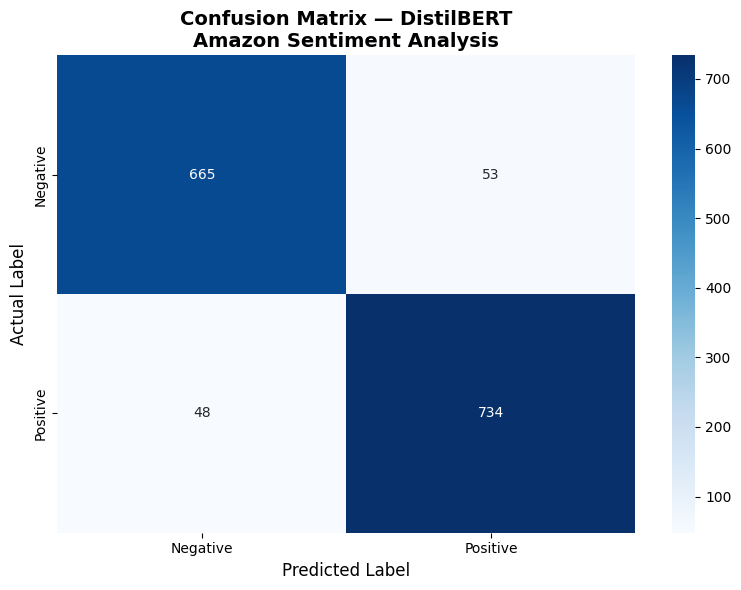

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.title('Confusion Matrix — DistilBERT\nAmazon Sentiment Analysis',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual Label',    fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


In [ ]:
print("=" * 60)
print("      EXAMPLE PREDICTIONS")
print("=" * 60)

label_names = {0: 'Negative', 1: 'Positive'}

sample_indices = range(10)

for i in sample_indices:
    review      = test_df['text'].iloc[i]
    true_label  = test_df['label'].iloc[i]
    pred_label  = preds[i]

    short_review = review[:80] + "..." if len(review) > 80 else review

    print(f"\nReview    : {short_review}")
    print(f"Actual    : {label_names[true_label]}")
    print(f"Predicted : {label_names[pred_label]}")
    print(f"Correct?  : {'Yes' if true_label == pred_label
                         else 'No'}")
    print("-" * 60)

      EXAMPLE PREDICTIONS

Review    : Classic Kurosawa/Mifune: Any cinema fan will note the opening wedding scene in T...
Actual    : Positive
Predicted : Positive
Correct?  : Yes
------------------------------------------------------------

Review    : Great Coffee Maker!: I have had this Kurig long enough to realize just how good ...
Actual    : Positive
Predicted : Positive
Correct?  : Yes
------------------------------------------------------------

Review    : Second Grade Fantastic: When this arrived, I was surprised by the smallness of i...
Actual    : Positive
Predicted : Positive
Correct?  : Yes
------------------------------------------------------------

Review    : SILLY SOAP OPERA: Two and a half hours of god awful, boring, nonsense about tish...
Actual    : Negative
Predicted : Negative
Correct?  : Yes
------------------------------------------------------------

Review    : Great for native japanese speakers: First I have to say I am disappointed that I...
Actual    : N

In [ ]:
print("=" * 50)
print("        FINAL MODEL SUMMARY")
print("=" * 50)
print(f"Model      : DistilBERT (distilbert-base-uncased)")
print(f"Task       : Binary Sentiment Classification")
print(f"Classes    : Negative (0) vs Positive (1)")
print(f"Dataset    : Amazon Product Reviews")
print(f"Train Size : {len(train_df)}")
print(f"Val Size   : {len(val_df)}")
print(f"Test Size  : {len(test_df)}")
print(f"Epochs     : 3")
print(f"Batch Size : 16")
print(f"LR         : 2e-5")
print("-" * 50)
print(f"Accuracy   : {accuracy*100:.2f}%")
print(f"Precision  : {precision*100:.2f}%")
print(f"Recall     : {recall*100:.2f}%")
print(f"F1 Score   : {f1*100:.2f}%")
print("=" * 50)

        FINAL MODEL SUMMARY
Model      : DistilBERT (distilbert-base-uncased)
Task       : Binary Sentiment Classification
Classes    : Negative (0) vs Positive (1)
Dataset    : Amazon Product Reviews
Train Size : 7004
Val Size   : 1496
Test Size  : 1500
Epochs     : 3
Batch Size : 16
LR         : 2e-5
--------------------------------------------------
Accuracy   : 93.27%
Precision  : 93.27%
Recall     : 93.27%
F1 Score   : 93.27%


In [9]:
!git config --global user.f2023065346@umt.edu.pk
!git config --global user.Eisha373

In [10]:
!git clone https://github.com/Eisha373/Amazon-sentiment-analysis.git

fatal: destination path 'Amazon-sentiment-analysis' already exists and is not an empty directory.
